In [18]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

In [19]:
df = pd.read_csv("alexandria_weather_2024_cleaned.csv")

In [20]:
df.head(10)

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,cloud_cover_mean,shortwave_radiation_sum
0,1/1/2020,13.2,16.0,11.1,1.7,82,16.9,1017.1,52,9.10
1,1/2/2020,12.9,15.4,10.3,2.2,73,28.2,1014.1,58,9.53
2,1/3/2020,11.6,13.4,9.3,7.4,79,39.5,1014.9,48,9.66
3,1/4/2020,13.4,15.0,12.4,16.0,83,30.3,1015.9,66,8.35
4,1/5/2020,13.5,16.2,11.3,1.2,77,24.0,1015.7,50,8.64
5,1/6/2020,13.3,17.0,10.7,2.0,65,37.0,1011.2,38,11.51
6,1/7/2020,11.8,13.8,9.2,2.0,70,40.8,1012.0,34,11.63
7,1/8/2020,13.0,14.8,11.9,25.1,81,39.6,1014.4,55,7.98
8,1/9/2020,12.6,14.2,11.2,18.8,80,30.8,1014.5,51,8.59
9,1/10/2020,13.6,15.4,11.7,3.0,77,27.8,1017.1,41,9.30


In [21]:
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)

In [22]:
df.head()

,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,cloud_cover_mean,shortwave_radiation_sum
time,,,,,,,,,
2020-01-01,13.2,16.0,11.1,1.7,82,16.9,1017.1,52,9.10
2020-01-02,12.9,15.4,10.3,2.2,73,28.2,1014.1,58,9.53
2020-01-03,11.6,13.4,9.3,7.4,79,39.5,1014.9,48,9.66
2020-01-04,13.4,15.0,12.4,16.0,83,30.3,1015.9,66,8.35
2020-01-05,13.5,16.2,11.3,1.2,77,24.0,1015.7,50,8.64


In [23]:
print(pd.infer_freq(df.index))

D


In [24]:
df.isnull().sum()

temperature_2m_mean          0
temperature_2m_max           0
temperature_2m_min           0
precipitation_sum            0
relative_humidity_2m_mean    0
wind_speed_10m_max           0
surface_pressure_mean        0
cloud_cover_mean             0
shortwave_radiation_sum      0
dtype: int64

In [26]:
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.dayofweek

In [27]:
df["is_Weekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [28]:
df["Lag_1"] = df["temperature_2m_mean"].shift(1)

df["Lag_7"] = df["temperature_2m_mean"].shift(7)

In [29]:
df["Rolling_Mean_7"] = df["temperature_2m_mean"].rolling(7).mean()
df["Rolling_STD_7"] = df["temperature_2m_mean"].rolling(7).std()

In [30]:
df.dropna(inplace=True)

In [31]:
df.head()

,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,wind_speed_10m_max,surface_pressure_mean,cloud_cover_mean,shortwave_radiation_sum,Month,DayOfWeek,is_Weekend,Lag_1,Lag_7,Rolling_Mean_7,Rolling_STD_7
time,,,,,,,,,,,,,,,,
2020-01-08,13.0,14.8,11.9,25.1,81,39.6,1014.4,55,7.98,1,2,0,11.8,13.2,12.785714,0.773366
2020-01-09,12.6,14.2,11.2,18.8,80,30.8,1014.5,51,8.59,1,3,0,13.0,12.9,12.742857,0.774289
2020-01-10,13.6,15.4,11.7,3.0,77,27.8,1017.1,41,9.30,1,4,0,12.6,11.6,13.028571,0.639568
2020-01-11,13.3,17.7,9.0,0.0,76,9.0,1022.3,77,9.12,1,5,1,13.6,13.4,13.014286,0.630948
2020-01-12,14.1,17.4,10.7,0.0,74,18.9,1022.8,48,12.16,1,6,1,13.3,13.5,13.100000,0.739369


In [34]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1456, 15)
(364, 15)
(1456,)
(364,)


In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["temperature_2m_mean"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.0911610853903864
p-value: 0.24808359505427013


In [39]:
df["temp_diff"] = df["temperature_2m_mean"].diff()

df = df.dropna()

In [40]:
result = adfuller(df["temp_diff"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.339572567971537
p-value: 3.8474539811439875e-28


In [47]:
target = "temperature_2m_mean"
X = df.drop(columns=[target])
y = df[target]

In [49]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

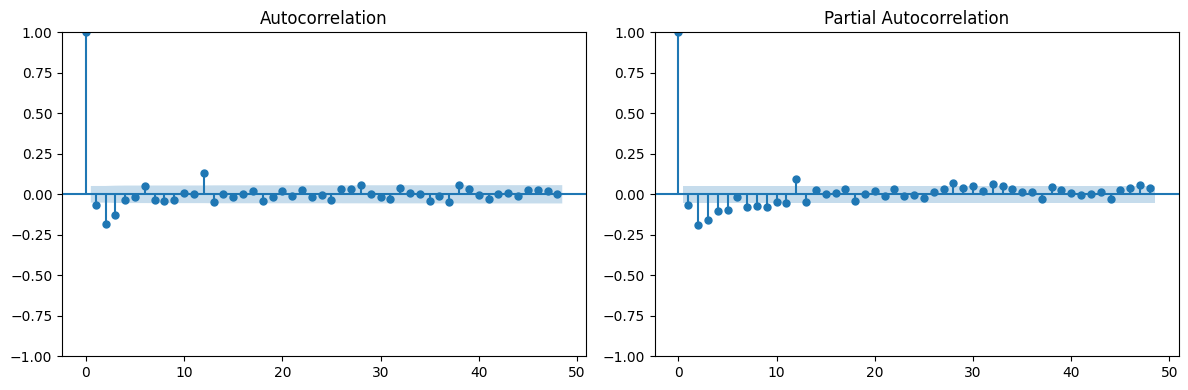

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(12,4))

plot_acf(X_train["temp_diff"].dropna(), lags=48, ax=axes[0])
plot_pacf(X_train["temp_diff"].dropna(), lags=48, ax=axes[1])

plt.tight_layout()
plt.show()

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,30)
)

model_fit = model.fit()

print(model_fit.summary())

c:\Users\Kiro\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Kiro\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                temperature_2m_mean   No. Observations:                 1455
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood               -2322.145
Date:                            Wed, 05 Aug 2026   AIC                           4654.290
Time:                                    23:44:14   BIC                           4680.596
Sample:                                01-09-2020   HQIC                          4664.115
                                     - 01-02-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6204      0.033     18.965      0.000       0.556       0.685
ma.L1         -0.8511      0.023   

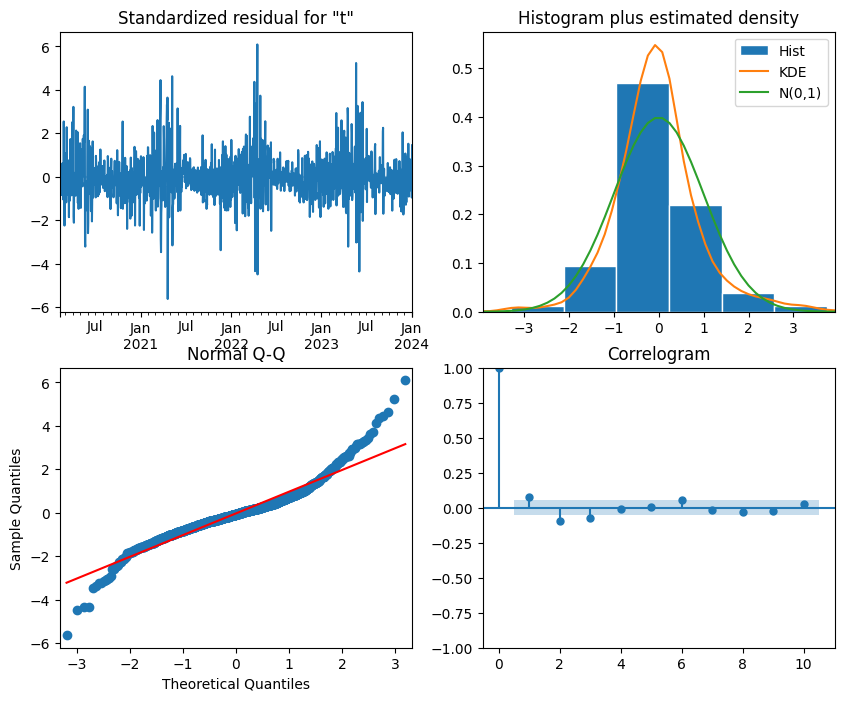

In [52]:
model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

In [53]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    model_fit.resid.dropna(),
    lags=[24],
    return_df=True
)

print(lb)

      lb_stat  lb_pvalue
24  70.077611   0.000002


In [54]:
forecast = model_fit.get_forecast(steps=len(y_test))

pred_mean = forecast.predicted_mean

ci = forecast.conf_int(alpha=0.05)

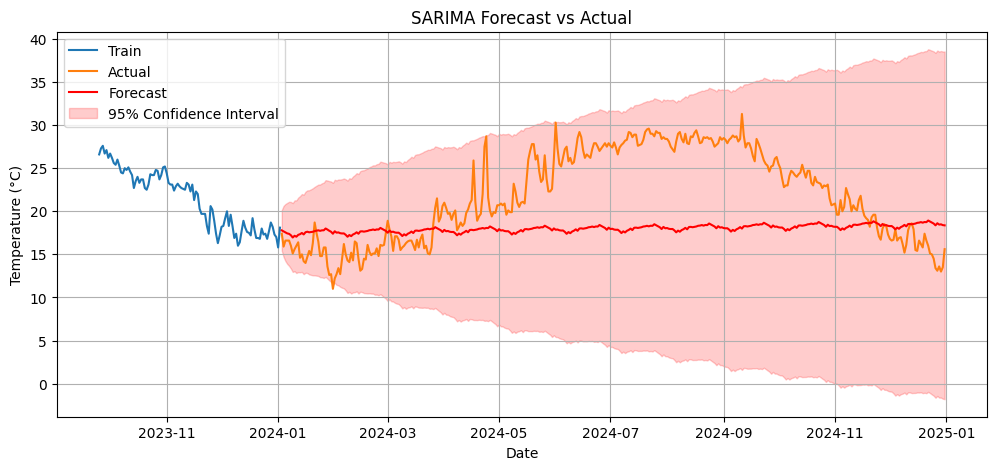

In [55]:
plt.figure(figsize=(12,5))

plt.plot(y_train.index[-100:], y_train[-100:], label="Train")

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(pred_mean.index, pred_mean, color="red", label="Forecast")

plt.fill_between(
    ci.index,
    ci.iloc[:,0],
    ci.iloc[:,1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred_mean)

rmse = np.sqrt(mean_squared_error(y_test, pred_mean))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 5.264171691323183
RMSE: 6.422881751678174
